In [4]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# 1. SETUP: Load the dataset
# Make sure "amman_market_data.csv" is in the same folder as this script
import os
print(os.getcwd()) 

c:\Users\DELL\m4-s2-Jumana\contributions\Jumana-ML


In [6]:
file_path = file_path = "amman_market_data.csv"
df = pd.read_csv(file_path)
df = df.copy()
print(df.head())

   order_id  customer_id  order_date     status  item_id  product_id  \
0         1            1  2024-01-05  completed        1           1   
1         1            1  2024-01-05  completed        2           6   
2         1            1  2024-01-05  completed        3          26   
3         2            2  2024-01-06  completed        4          17   
4         2            2  2024-01-06  completed        5          21   

   quantity                  product_name         category  unit_price  \
0         2    Wireless Bluetooth Earbuds      Electronics        45.0   
1         1                Cotton T-Shirt         Clothing        18.0   
2         3      Arabic Coffee Blend 500g  Food & Beverage        18.0   
3         1  Python Data Science Handbook            Books        55.0   
4         2                      Yoga Mat           Sports        28.0   

        customer_name                      email   city registration_date  \
0      Ahmad Al-Masri      ahmad.masri@email.

In [7]:
# 2. DATA INSPECTION: Quick look at the structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           1081 non-null   int64  
 1   customer_id        1081 non-null   int64  
 2   order_date         1081 non-null   str    
 3   status             1081 non-null   str    
 4   item_id            1081 non-null   int64  
 5   product_id         1081 non-null   int64  
 6   quantity           1081 non-null   int64  
 7   product_name       1081 non-null   str    
 8   category           1081 non-null   str    
 9   unit_price         1081 non-null   float64
 10  customer_name      1081 non-null   str    
 11  email              1081 non-null   str    
 12  city               1081 non-null   str    
 13  registration_date  1081 non-null   str    
 14  line_total         1081 non-null   float64
dtypes: float64(2), int64(5), str(8)
memory usage: 126.8 KB


In [8]:
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 1081 rows and 15 columns.


In [9]:
# 3. DATA PROCESSING: Sorting for Dominant Category Logic
# We sort by Order ID, then by Line Total (Largest amount first)
# This ensures the most expensive item in every order appears at the top
df = df.sort_values(by=['order_id', 'line_total'], ascending=[True, False])

In [10]:
print(df[['order_id', 'category', 'line_total']].head(20))

    order_id         category  line_total
0          1      Electronics        90.0
2          1  Food & Beverage        54.0
1          1         Clothing        18.0
4          2           Sports        56.0
3          2            Books        55.0
6          4    Home & Garden        96.0
5          4         Clothing        78.0
7          4           Sports        19.0
9          5  Food & Beverage        96.0
8          5      Electronics        32.0
11         6            Books        85.0
10         6         Clothing        60.0
12         7      Electronics        55.0
13         7    Home & Garden        45.0
14         7  Food & Beverage         9.5
16         8    Home & Garden        65.0
15         8         Clothing        52.0
18         9            Books        42.0
19         9           Sports        28.0
17         9      Electronics        25.5


In [11]:
# Calculate the total amount for each order (Sum of all items in the cart)
df['order_total'] = df.groupby('order_id')['line_total'].transform('sum')

In [12]:
orders = df.drop_duplicates('order_id').reset_index()

In [13]:
print(df[['order_id', 'category', 'line_total' , 'order_total']].head(20))

    order_id         category  line_total  order_total
0          1      Electronics        90.0        162.0
2          1  Food & Beverage        54.0        162.0
1          1         Clothing        18.0        162.0
4          2           Sports        56.0        111.0
3          2            Books        55.0        111.0
6          4    Home & Garden        96.0        193.0
5          4         Clothing        78.0        193.0
7          4           Sports        19.0        193.0
9          5  Food & Beverage        96.0        128.0
8          5      Electronics        32.0        128.0
11         6            Books        85.0        145.0
10         6         Clothing        60.0        145.0
12         7      Electronics        55.0        109.5
13         7    Home & Garden        45.0        109.5
14         7  Food & Beverage         9.5        109.5
16         8    Home & Garden        65.0        117.0
15         8         Clothing        52.0        117.0
18        

In [14]:
# 4. AGGREGATION: Create an 'Orders' level dataframe
# 'line_total': sum (The full price the customer paid)
# 'category': 'first' (The category of the most expensive item in that order)
orders = df.groupby('order_id').agg({
        'line_total': 'sum',   
        'category': 'first'     
    }).reset_index()

In [15]:
print(orders)

     order_id  line_total         category
0           1       162.0      Electronics
1           2       111.0           Sports
2           4       193.0    Home & Garden
3           5       128.0  Food & Beverage
4           6       145.0            Books
..        ...         ...              ...
438       495       105.0            Books
439       496       189.0         Clothing
440       498        32.5           Sports
441       499       101.0      Electronics
442       500       157.0         Clothing

[443 rows x 3 columns]


In [16]:
print(orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    443 non-null    int64  
 1   line_total  443 non-null    float64
 2   category    443 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 10.5 KB
None


In [17]:
# 5. ANALYSIS: Calculate Average Order Value (AOV) per Category
# We group by the dominant category and find the median of the total order values
aov_data = orders.groupby('category')['line_total'].median().sort_values(ascending=False)

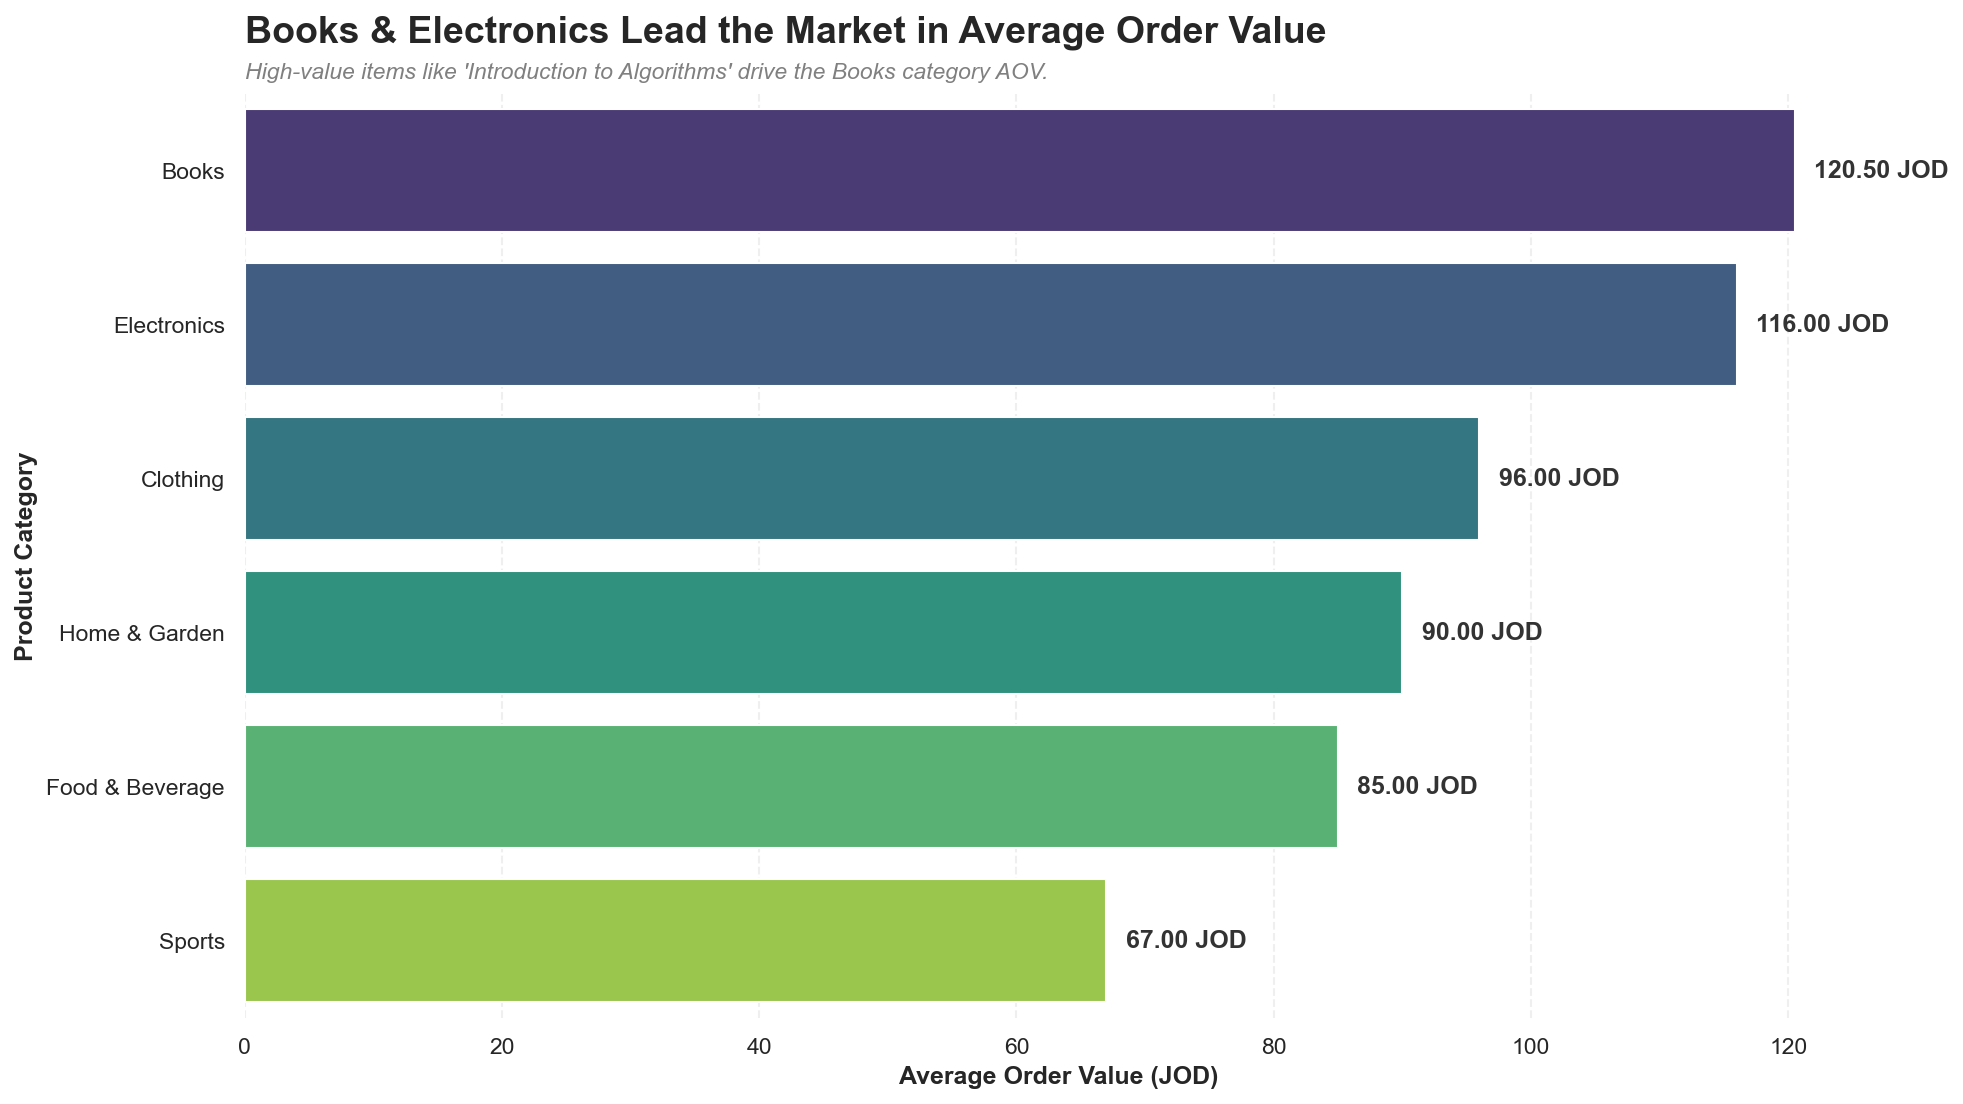

In [ ]:
# 6. PROFESSIONAL VISUALIZATION: Setting up the High-Res Chart
# 'white' style for a clean, corporate look
sns.set_theme(style="white")

# Create the Bar Plot
plt.figure(figsize=(14, 8), dpi=150)

# hue=index ensures every category gets a unique color without warnings
ax = sns.barplot(
    x=aov_data.values, 
    y=aov_data.index, 
    hue=aov_data.index, 
    palette="viridis", 
    legend=False
)

# 7. DATA LABELS: Adding the exact JOD value at the end of each bar
# Using a manual loop for better understanding
row_index = 0 
for value in aov_data.values:
    # Put text at (X = value + small gap, Y = current row index)
    # .2f formats the number to 2 decimal places
    x_position = value + 1.5
    y_position = row_index
    label_text = f'{value:.2f} JOD'
    ax.text(x_position, 
            y_position, 
            label_text, 
            va='center',       
            fontweight='bold',  
            color='#333')       
    
    row_index = row_index + 1

# 8. TYPOGRAPHY: Titles and Subtitles
plt.title("Books & Electronics Lead the Market in Average Order Value", 
          fontsize=18, fontweight='bold', pad=25, loc='left')
# Adding an analytical subtitle explaining our "Dominant Category" finding
plt.text(0, -0.6, "High-value items like 'Introduction to Algorithms' drive the Books category AOV.", 
         fontsize=11, color='gray', style='italic')

plt.xlabel("Average Order Value (JOD)", fontsize=12, fontweight='semibold')
plt.ylabel("Product Category", fontsize=12, fontweight='semibold')

# 9. FINAL POLISH: Removing unnecessary borders (Chart Junk)
sns.despine(left=True, bottom=True)
ax.grid(axis='x', linestyle='--', alpha=0.3) # Subtle vertical grid lines
# 10. SAVE & EXPORT: Saving the file in HD format for presentations
plt.savefig('market_analysis_high.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. Macro Analysis: Calculate mean, count, and price range per category
# Output shows Books has the highest mean (129.06) and the highest max order (277.0)
check_logic = orders.groupby('category')['line_total'].agg(['mean', 'count', 'max', 'min'])
print(check_logic.sort_values(by='mean', ascending=False))

                       mean  count    max   min
category                                       
Books            129.064815    108  277.0  50.5
Electronics      119.057143    105  240.0  26.5
Clothing         102.606796    103  271.0  27.5
Home & Garden     99.364286     70  231.0  23.5
Food & Beverage   86.074074     27  148.0  18.0
Sports            80.450000     30  177.0  20.5


In [ ]:
# 2. Filtering: Isolate 'Books' orders and sort by total value
# Output identifies Order ID 167 as the record-breaking transaction (277.0 JOD)
top_books_orders = orders[orders['category'] == 'Books'].sort_values(by='line_total', ascending=False)

In [21]:
print(top_books_orders.head(5))

     order_id  line_total category
146       167       277.0    Books
427       483       257.0    Books
365       413       250.0    Books
78         89       234.0    Books
63         72       233.0    Books


In [ ]:
# 3. Investigation: Extract the full cart content for the top book order (ID 167)
# Output reveals a mix of Books, Electronics, and Food in the same transaction
order_id_to_check = top_books_orders.iloc[0]['order_id']
print(df[df['order_id'] == order_id_to_check])

     order_id  customer_id  order_date     status  item_id  product_id  \
355       167           58  2024-07-23  completed      411          16   
354       167           58  2024-07-23  completed      410           4   
356       167           58  2024-07-23  completed      412          26   

     quantity                product_name         category  unit_price  \
355         2  Introduction to Algorithms            Books        85.0   
354         1         Mechanical Keyboard      Electronics        89.0   
356         1    Arabic Coffee Blend 500g  Food & Beverage        18.0   

        customer_name                    email    city registration_date  \
355  Iman Al-Masalmeh  iman.masalmeh@email.com  Madaba        2024-05-28   
354  Iman Al-Masalmeh  iman.masalmeh@email.com  Madaba        2024-05-28   
356  Iman Al-Masalmeh  iman.masalmeh@email.com  Madaba        2024-05-28   

     line_total  order_total  
355       170.0        277.0  
354        89.0        277.0  
356     

In [ ]:
# 4. Final Proof: Compare specific line totals to justify the 'Books' classification
# The "Smoking Gun": Books (170.0 JOD) > Electronics (89.0 JOD)
# This confirms the order is categorized as 'Books' because the books were more expensive
check_order = df[df['order_id'] == 167]
print(check_order[['order_id', 'product_name', 'quantity', 'unit_price', 'line_total']])

     order_id                product_name  quantity  unit_price  line_total
355       167  Introduction to Algorithms         2        85.0       170.0
354       167         Mechanical Keyboard         1        89.0        89.0
356       167    Arabic Coffee Blend 500g         1        18.0        18.0
